In [26]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import subprocess
import sys

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import classification_report as cr
from xgboost import XGBClassifier

# Custom Implementations
from logger import Logger
from Costs import get_cost_matrix, get_sample_weights, RAW_FN_COSTS, RAW_FP_COST, CLASS_TO_IDX, predict_cost_sensitive
from Evaluation import show_classification_report, show_confusion_matrix, compare_tel, plot_cost_roc, plot_ablation, report_tel
from Preprocessing import drop_low_variance_cols, log_transform, make_label_encoder, build_features, apply_smote, make_calibration_split

# Common Init

In [3]:
log = Logger()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
log.success("Initialisation complete")

[21:23:45] [success]: Initialisation complete


# Data Setup

In [4]:
PROCESSED_DIR = '../data/processed'
REQUIRED_FILES = ["nslkdd_train.csv", "nslkdd_validation.csv", "nslkdd_test.csv"]

missing = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(PROCESSED_DIR, f))]

if missing:
    log.warn("Data missing, downloading...")
    result = subprocess.run([sys.executable, "Setup.py"], capture_output=False)
    if result.returncode != 0:
        raise RuntimeError("setup.py failed")
    log.success("Data Downloaded and processed")
else:
    log.success("Data available")

[21:23:45] [warning]: Data missing, downloading...
[21:23:47] [success]: Data Downloaded and processed


# Data Pipeline

## Load Splits

In [5]:
DATA_DIR = "data/processed"

train_df = pd.read_csv(f'{DATA_DIR}/nslkdd_train.csv')
val_df = pd.read_csv(f'{DATA_DIR}/nslkdd_validation.csv')
test_df = pd.read_csv(f'{DATA_DIR}/nslkdd_test.csv')

TARGET = 'macro_label'

X_train_raw = train_df.drop(columns=[TARGET])
y_train_raw = train_df[TARGET]
X_val_raw   = val_df.drop(columns=[TARGET])
y_val_raw   = val_df[TARGET]
X_test_raw  = test_df.drop(columns=[TARGET])
y_test_raw  = test_df[TARGET]

## Label Encoding

In [6]:
encoder, y_train_enc, y_val_enc, y_test_enc = make_label_encoder(y_train_raw, y_val_raw, y_test_raw)

## Imbalance Audit

In [7]:
counts = y_train_raw.value_counts()
majority = counts.max()

audit = pd.DataFrame({'count': counts, 'percentage': (counts / len(train_df) * 100).round(2)})
audit['imbalance_ration'] = (majority / counts).round(1)

log.info("Training set class distribution: ")
log.info(audit.to_string())


[21:23:47] [info]: Training set class distribution: 
[21:23:47] [info]:              count  percentage  imbalance_ration
macro_label                                     
Normal       53874       53.46               1.0
DoS          36741       36.46               1.5
Probe         9325        9.25               5.8
R2L            796        0.79              67.7
U2R             42        0.04            1282.7


## Feature Preprocessing

This preprocessing is common across all models

In [8]:
X_train_scaled, X_val_scaled, X_test_scaled, scaler, features = build_features(X_train_raw, X_val_raw, X_test_raw)

# Human readable test DataFrame for plotting
X_test_human, _, _ = drop_low_variance_cols(X_test_raw, X_val_raw, X_train_raw)
X_test_human, _, _ = log_transform(X_test_human, X_val_raw, X_train_raw)

log.info(f"Feature matrix after preprocessing: {X_train_scaled.shape}")
log.info(f"Features: {features}")


[21:23:48] [info]: Feature matrix after preprocessing: (100778, 38)
[21:23:48] [info]: Features: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## Calibration Split

In [9]:
X_calib, X_val_eval, y_calib_enc, y_val_eval_enc = make_calibration_split(X_val_scaled, y_val_enc)

## Resampling

SMOTE + ENN Resampling used by cost-sensitive models

In [10]:
X_train_res, y_train_res = apply_smote(X_train_scaled, y_train_enc)

log.info('After SMOTE+ENN: ')
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    log.info(f"{encoder.inverse_transform([u])[0]:8s}: {c:,}")

[21:24:12] [info]: After SMOTE+ENN: 
[21:24:12] [info]: DoS     : 36,710
[21:24:12] [info]: Normal  : 53,568
[21:24:12] [info]: Probe   : 14,893
[21:24:12] [info]: R2L     : 19,978
[21:24:12] [info]: U2R     : 4,993


# Cost Matrix

We define 3 regimes. All models are evaluated against all three, producing the ablation study we do later

In [11]:
REGIMES = ['conservative', 'moderate', 'aggressive']

for regime in REGIMES:
    cm = get_cost_matrix(regime)
    df_cm = pd.DataFrame(
        cm, 
        index=[f"pred_{encoder.inverse_transform([i])[0]}" for i in range(5)], 
        columns=[f"true_{encoder.inverse_transform([i])[0]}" for i in range(5)])
    
    log.info(f"{regime.upper()} Cost Matrix: ")
    log.info(df_cm.round(2).to_string())

COST_MATRIX = get_cost_matrix()

[21:24:12] [info]: CONSERVATIVE Cost Matrix: 
[21:24:12] [info]:              true_DoS  true_Normal  true_Probe  true_R2L  true_U2R
pred_DoS         0.00          1.0        1.76      2.29      2.49
pred_Normal      2.14          0.0        1.76      2.29      2.49
pred_Probe       2.14          1.0        0.00      2.29      2.49
pred_R2L         2.14          1.0        1.76      0.00      2.49
pred_U2R         2.14          1.0        1.76      2.29      0.00
[21:24:12] [info]: MODERATE Cost Matrix: 
[21:24:12] [info]:              true_DoS  true_Normal  true_Probe  true_R2L  true_U2R
pred_DoS         0.00          1.0        8.82     11.47     12.44
pred_Normal     10.71          0.0        8.82     11.47     12.44
pred_Probe      10.71          1.0        0.00     11.47     12.44
pred_R2L        10.71          1.0        8.82      0.00     12.44
pred_U2R        10.71          1.0        8.82     11.47      0.00
[21:24:12] [info]: AGGRESSIVE Cost Matrix: 
[21:24:12] [info]:        

# Models

We train 4 models as defined below:
1. Baseline RF: Optimised for Accuracy with no class weighting and no SMOTE
2. Cost-Sensitive RF: Class weights and SMOTE used
3. Baseline XGBoost: Optimised for Accuracy
4. Cost-Sensitive XGBoost: Sample weights derived from cost matrix + SMOTE

The models share identical preprocessing. Cost-sensitive inference uses predict_cost_sensitive() from our custom library. 

The cost matrix and training weights are always derived from the same economic source.

In [12]:
def calibrate(fitted_model, X_calib, y_calib_enc):
    cal = CalibratedClassifierCV(FrozenEstimator(fitted_model), method='sigmoid')
    cal.fit(X_calib, y_calib_enc)
    return cal

## Baseline RF Training

In [13]:
log.info("Baseline RF training...")
base_rf = RandomForestClassifier(n_estimators=2000, random_state=RANDOM_STATE, n_jobs=-1)
base_rf.fit(X_train_scaled, y_train_enc)
cal_base_rf = calibrate(base_rf, X_calib, y_calib_enc)
log.success("Done")

[21:24:12] [info]: Baseline RF training...
[21:24:46] [success]: Done


## Cost-Sensitive RF Training

Class weights are derived from the moderate cost matrix FN column so it stays consistent with the inference cost matrix

In [14]:
fn_col = {i: COST_MATRIX[i, CLASS_TO_IDX['Normal']] for i in range(5)}
fn_col[CLASS_TO_IDX['Normal']] = 1.0 # Normal has no FN cost
log.info(f'Class weights derived from cost matrix: {fn_col}')

[21:24:46] [info]: Class weights derived from cost matrix: {0: np.float64(1.0), 1: 1.0, 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [15]:
log.info('Cost-Sensitive RF training...')
cost_rf = RandomForestClassifier(n_estimators=500, max_depth=25, min_samples_split=5, min_samples_leaf=5, max_features='sqrt', bootstrap=True, class_weight=fn_col, random_state=RANDOM_STATE, n_jobs=-1)

cost_rf.fit(X_train_res, y_train_res)
cal_cost_rf = calibrate(cost_rf, X_calib, y_calib_enc)
log.success("Done")

[21:24:46] [info]: Cost-Sensitive RF training...
[21:25:00] [success]: Done


## Baseline XGBoost

In [16]:
log.info('Baseline XGBoost training...')
base_xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7, objective='multi:solfprob', num_class=5, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
base_xgb.fit(X_train_scaled, y_train_enc)
cal_base_xgb = calibrate(base_xgb, X_calib, y_calib_enc)
log.success("Done")

[21:25:00] [info]: Baseline XGBoost training...
[21:25:08] [success]: Done


## Cost-Sensitive XGBoost

In [17]:
sample_weights = get_sample_weights(y_train_res)
log.info(f'Sample weight range: { sample_weights.min().round(2)} - {sample_weights.max().round(2)}')

[21:25:08] [info]: Sample weight range: 1.0 - 12.44


In [18]:
log.info('Cost-Sensitive XGBoost training...')
cost_xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7, objective='multi:softprob', num_class=5, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
cost_xgb.fit(X_train_res, y_train_res, sample_weights)
cal_cost_xgb = calibrate(cost_xgb, X_calib, y_calib_enc)
log.success("Done")

[21:25:08] [info]: Cost-Sensitive XGBoost training...
[21:25:22] [success]: Done


## Prediction Generation

Here we are going to store standard and cost-sensitive predictions so the SHAP correction analysis can find samples where they diverge.

In [19]:
MODELS = {
    "Baseline RF": (cal_base_rf, base_rf),
    "Cost-Sensitive RF": (cal_cost_rf, cost_rf),
    "Baseline XGB": (cal_base_xgb, base_xgb),
    "Cost-Sensitive XGB": (cal_cost_xgb, cost_xgb)
}

preds = {}

for name, (cal_model, _) in MODELS.items():
    probas = cal_model.predict_proba(X_test_scaled)
    simple_enc = np.argmax(probas, axis=1)
    cost_enc = predict_cost_sensitive(cal_model, X_test_scaled, COST_MATRIX)
    preds[name] = {
        'probas': probas,
        "simple_enc": simple_enc,
        "cost_enc": cost_enc
    }

    n_corrections = (simple_enc != cost_enc).sum()
    log.info(f"{name}: {n_corrections} predictions changed by cost-sensitive inference")


[21:25:24] [info]: Baseline RF: 584 predictions changed by cost-sensitive inference
[21:25:25] [info]: Cost-Sensitive RF: 897 predictions changed by cost-sensitive inference
[21:25:25] [info]: Baseline XGB: 183 predictions changed by cost-sensitive inference
[21:25:26] [info]: Cost-Sensitive XGB: 253 predictions changed by cost-sensitive inference


# Explainability

In [20]:
# TODO: ...

# Evaluation

We use 4 metrics for every model:

1. Classification report: precision / recall / F1 per class
2. Total Economic Loss (TEL): our primary metric grounded in dollar values
3. Cost-ROC curves: recall vs FPR for R2L and U2R specifically
4. Spearman ρ: quantitative attentional shift between baseline and cost-sensitive SHAP

Finally we do an ablation study across all three cost regimes

## Classification Reports

In [21]:
for name, (cal_model, _) in MODELS.items():
    y_pred = encoder.inverse_transform(preds[name]["cost_enc"])
    show_classification_report(y_test_raw, y_pred, encoder, title=name)
    show_confusion_matrix(y_test_enc, preds[name]['cost_enc'], encoder)

[21:25:26] [info]: BASELINE RF
[21:25:26] [info]:               precision    recall  f1-score   support

         DoS       0.96      0.82      0.89      7460
      Normal       0.69      0.97      0.80      9711
       Probe       0.85      0.79      0.82      2421
         R2L       0.98      0.06      0.12      2885
         U2R       0.60      0.09      0.16        67

    accuracy                           0.78     22544
   macro avg       0.81      0.55      0.56     22544
weighted avg       0.83      0.78      0.74     22544

[21:25:26] [info]: Confusion Matrix: 
[21:25:26] [info]: df.to_string()
[21:25:26] [info]: COST-SENSITIVE RF
[21:25:26] [info]:               precision    recall  f1-score   support

         DoS       0.96      0.82      0.89      7460
      Normal       0.69      0.97      0.81      9711
       Probe       0.84      0.78      0.81      2421
         R2L       0.97      0.09      0.17      2885
         U2R       0.56      0.28      0.38        67

    acc

## Total Economic Loss


──────────────────────────────────────────────────
  Total Economic Loss — Baseline RF [moderate]
──────────────────────────────────────────────────
  TEL (total):     $4,093,873,725.00
  TEL from FN:     $4,093,870,000.00
  TEL from FP:     $       3,725.00

  FN breakdown:
    U2R     :     $ 179,550,000.00
    R2L     :     $3,212,400,000.00
    DoS     :     $ 672,000,000.00
    Probe   :     $  29,920,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Cost-Sensitive RF [moderate]
──────────────────────────────────────────────────
  TEL (total):     $3,908,598,750.00
  TEL from FN:     $3,908,595,000.00
  TEL from FP:     $       3,750.00

  FN breakdown:
    U2R     :     $ 132,300,000.00
    R2L     :     $3,068,400,000.00
    DoS     :     $ 677,040,000.00
    Probe   :     $  30,855,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Baseline XGB [moderate]
──────────────────────────────────────────────────
  TEL (

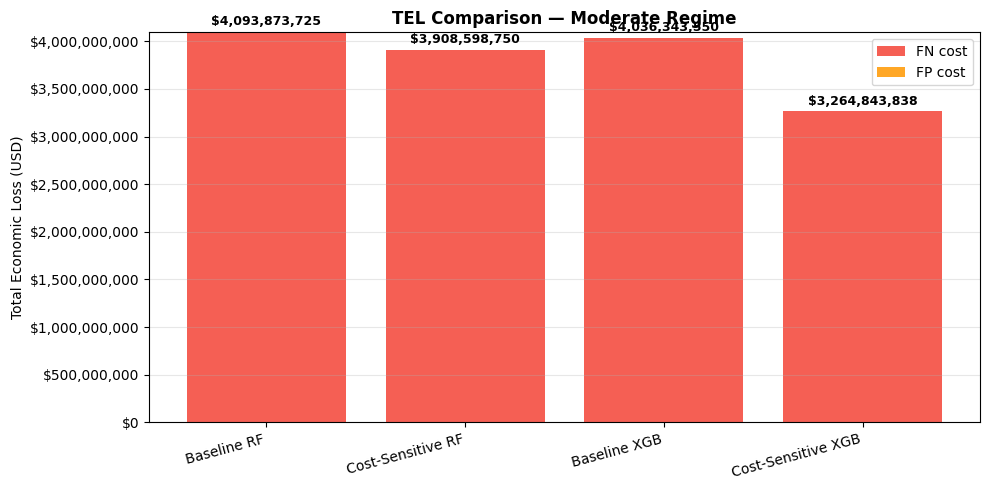

In [23]:
tel_results = {}
for name in MODELS:
    tel_results[name] = report_tel(y_test_enc, preds[name]['cost_enc'], name)

compare_tel(tel_results)

## Cost-ROC Curves

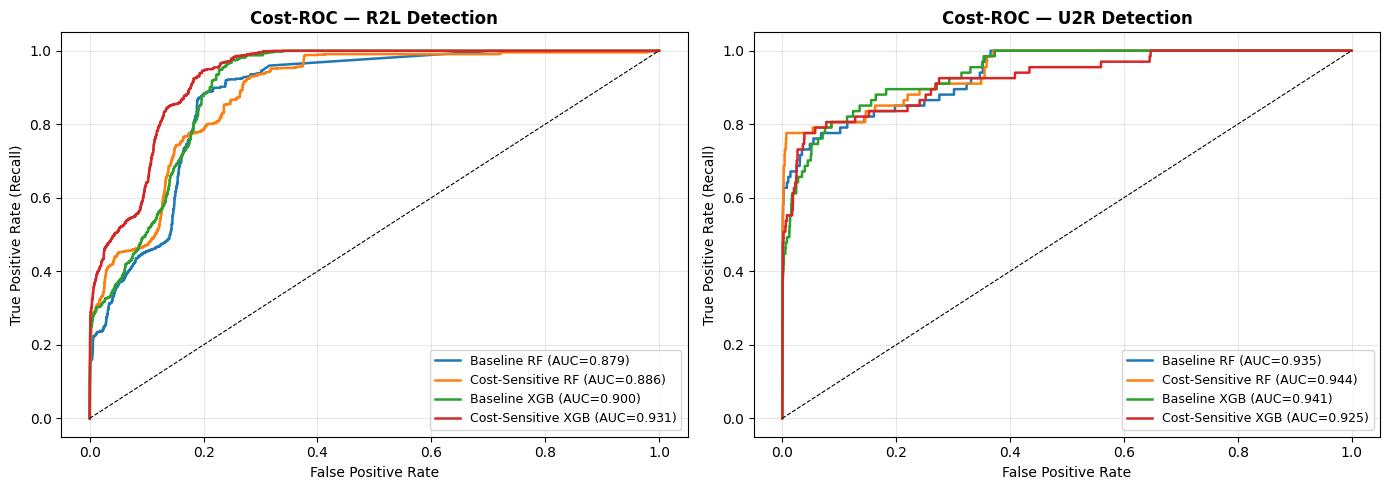

In [25]:
plot_cost_roc(models= {name: cal for name, (cal, _) in MODELS.items()}, X_test=X_test_scaled,  y_test_enc=y_test_enc, le=encoder, focus_classes=('R2L', 'U2R'))

## Spearman Rank Correlation

In [ ]:
# TBD

## Ablation Study

### Inference Only
Here we reevaluate cost-sensitive XGB predictions under each regime's cost matrix. Models are not retrained, we only infer cost matrix changes.


──────────────────────────────────────────────────
  Total Economic Loss — Cost XGB [conservative] [conservative]
──────────────────────────────────────────────────
  TEL (total):     $3,348,358,775.00
  TEL from FN:     $3,348,355,000.00
  TEL from FP:     $       3,775.00

  FN breakdown:
    U2R     :     $ 116,550,000.00
    R2L     :     $2,625,600,000.00
    DoS     :     $ 570,080,000.00
    Probe   :     $  36,125,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Cost XGB [moderate] [moderate]
──────────────────────────────────────────────────
  TEL (total):     $3,264,843,837.50
  TEL from FN:     $3,264,840,000.00
  TEL from FP:     $       3,837.50

  FN breakdown:
    U2R     :     $ 110,250,000.00
    R2L     :     $2,582,400,000.00
    DoS     :     $ 540,400,000.00
    Probe   :     $  31,790,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Cost XGB [aggressive] [aggressive]
─────────────────────────────

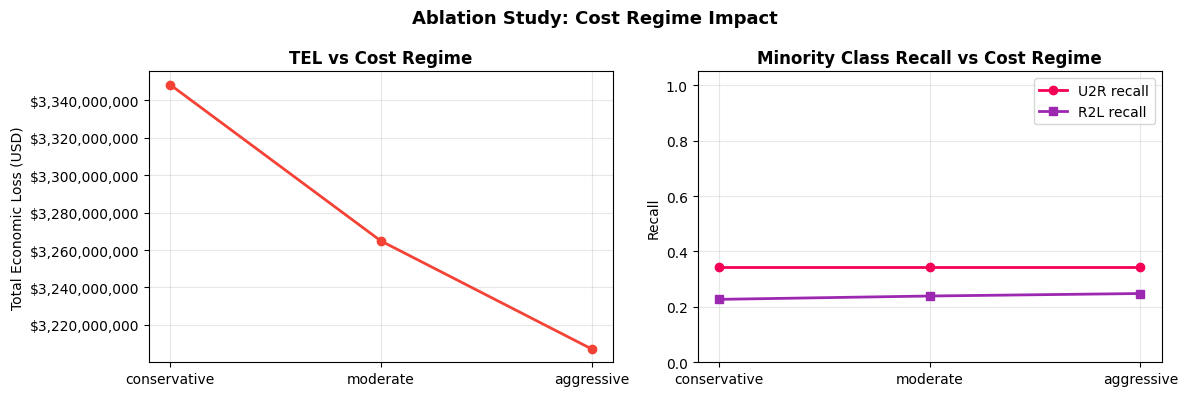

In [28]:
ablation_results = {}
for regime in REGIMES:
    cm_r = get_cost_matrix(regime)
    pred_enc = predict_cost_sensitive(cal_cost_xgb, X_test_scaled, cm_r)
    tel_r = report_tel(y_test_enc, pred_enc, model_name=f'Cost XGB [{regime}]', regime=regime)

    report = cr(y_test_enc, pred_enc, target_names=encoder.classes_, output_dict=True)
    u2r_recall = report.get('U2R', {}).get('recall', 0.0)
    r2l_recall = report.get('R2L', {}).get('recall', 0.0)

    ablation_results[regime] = {
        'tel': tel_r['TEL'],
        'u2r_recall': u2r_recall,
        'r2l_recall': r2l_recall,
    }

plot_ablation(ablation_results)

### Cost Regimes

For each regime we derive sample weights then we retrain, recalibrate and reevaluate XG.

The same architecture and SMOTE'd data is used across all regimes with only weight changes

[21:46:06] [info]: [Ablation] Training cost-sensitive XGB — regime: conservative
[21:46:14] [info]: 
[Ablation — conservative] Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.89      7460
      Normal       0.70      0.97      0.81      9711
       Probe       0.85      0.71      0.77      2421
         R2L       0.98      0.19      0.32      2885
         U2R       0.61      0.33      0.43        67

    accuracy                           0.80     22544
   macro avg       0.82      0.61      0.65     22544
weighted avg       0.84      0.80      0.77     22544


──────────────────────────────────────────────────
  Total Economic Loss — Cost-XGB [conservative] [moderate]
──────────────────────────────────────────────────
  TEL (total):     $3,573,898,562.50
  TEL from FN:     $3,573,895,000.00
  TEL from FP:     $       3,562.50

  FN breakdown:
    U2R     :     $ 119,700,000.00
    R2L     :     $2,772,000,000.00
 

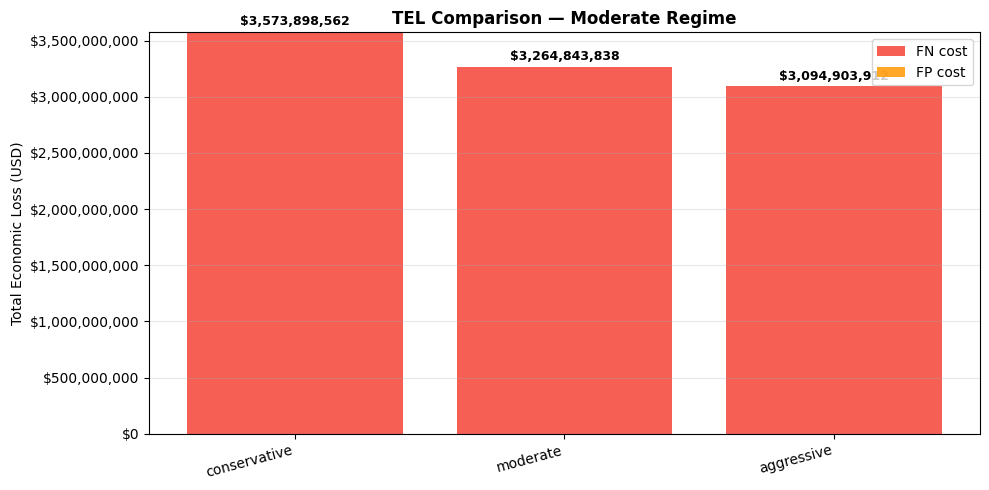

In [32]:
ablation_models = {}
ablation_preds  = {}
ablation_tel    = {}

for regime in REGIMES:
    log.info(f"[Ablation] Training cost-sensitive XGB — regime: {regime}")

    sample_weights = get_sample_weights(y_train_res, regime=regime)
    cost_matrix    = get_cost_matrix(regime=regime)

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb.fit(X_train_res, y_train_res, sample_weight=sample_weights)

    cal_xgb = calibrate(xgb, X_calib, y_calib_enc)

    preds_enc  = predict_cost_sensitive(cal_xgb, X_test_scaled, cost_matrix)
    preds_labels = encoder.inverse_transform(preds_enc)

    ablation_models[regime] = cal_xgb
    ablation_preds[regime]  = preds_enc

    log.info(f"\n[Ablation — {regime}] Classification Report:")
    log.blank(cr(
        encoder.inverse_transform(y_test_enc),
        preds_labels,
        target_names=encoder.classes_
    ))

    ablation_tel[regime] = report_tel(y_test_enc, preds_enc, f"Cost-XGB [{regime}]")

log.info("\n[Ablation] TEL comparison across regimes:")
compare_tel(ablation_tel)

# Results Summary

In [31]:
rows = []
for name in MODELS:
    report = cr(
        y_test_enc,
        preds[name]['cost_enc'],
        target_names=encoder.classes_,
        output_dict=True,
    )
    rows.append({
        'Model': name,
        'Macro F1': round(report['macro avg']['f1-score'], 3),
        'U2R Recall': round(report.get('U2R', {}).get('recall', 0), 3),
        'R2L Recall': round(report.get('R2L', {}).get('recall', 0), 3),
        'TEL (USD)': f"${tel_results[name]['TEL']:,.0f}",
        'TEL FN (USD)': f"${tel_results[name]['TEL_FN']:,.0f}",
    })

summary = pd.DataFrame(rows).set_index('Model')
log.warn('RESULTS SUMMARY')
log.info(summary.to_string())

[21:35:39] [warning]: RESULTS SUMMARY
[21:35:39] [info]:                     Macro F1  U2R Recall  R2L Recall       TEL (USD)    TEL FN (USD)
Model                                                                               
Baseline RF            0.556       0.090       0.063  $4,093,873,725  $4,093,870,000
Cost-Sensitive RF      0.611       0.284       0.095  $3,908,598,750  $3,908,595,000
Baseline XGB           0.574       0.104       0.089  $4,036,343,550  $4,036,340,000
Cost-Sensitive XGB     0.669       0.343       0.239  $3,264,843,838  $3,264,840,000
